In [ ]:
!pip install -q tensorflow pandas numpy scikit-learn nltk rouge-score matplotlib

In [ ]:
import nltk
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

TensorFlow Version: 2.21.0

Original Dataset Shape: (433845, 2)
Columns: ['english', 'telugu']

After Cleaning: (409338, 2)

Sample Preprocessed Sentences:
English: tom started his car and drove away
Telugu : టామ్ తన కారును స్టార్ట్ చేసి దూరంగా నడిపాడు

English: i think tom understands all that
Telugu : టామ్ అంతా అర్థం చేసుకున్నాడని నేను అనుకుంటున్నాను

English: i ll go tomorrow morning
Telugu : నేను రేపు ఉదయం వెళ్తాను

English: which do you recommend
Telugu : మీరు దేనిని సిఫార్సు చేస్తారు

English: in order to generate an accurate weather forecast for the next 24 hours i would need up to date weather data for a specific location
Telugu : రాబోయే గంటల్లో ఖచ్చితమైన వాతావరణ సూచనను రూపొందించడానికి ఒక నిర్దిష్ట స్థానం కోసం నాకు తాజా వాతావరణ డేటా అవసరం


Samples Used: 30000

Training Samples  : 24000
Validation Samples: 3000
Testing Samples   : 3000

English Vocabulary: 15000
Telugu Vocabulary : 20000

Encoder Shape: (24000, 30)
Decoder Shape: (24000, 29)
Target Shape : (24000, 29)

MODEL AR

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Encoder_Input       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_Input       │ (None, 29)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ English_Embedding   │ (None, 30, 128)   │  1,920,000 │ Encoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 30)        │          0 │ Encoder_Input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Telugu_Embedding    │ (None, 29, 128)   │  2,560,000 │ Decoder_Input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder_LSTM (LSTM) │ [(None, 30, 256), │    394,240 │ English_Embeddin… │
│                     │ (None, 256),      │            │ not_equal_2[0][0] │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder_LSTM (LSTM) │ [(None, 29, 256), │    394,240 │ Telugu_Embedding… │
│                     │ (None, 256),      │            │ Encoder_LSTM[0][… │
│                     │ (None, 256)]      │            │ Encoder_LSTM[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Attention           │ (None, 29, 256)   │          0 │ Decoder_LSTM[0][… │
│ (Attention)         │                   │            │ Encoder_LSTM[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Attention_Concaten… │ (None, 29, 512)   │          0 │ Decoder_LSTM[0][… │
│ (Concatenate)       │                   │            │ Attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Telugu_Output       │ (None, 29, 20000) │ 10,260,000 │ Attention_Concat… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,528,480 (59.24 MB)

 Trainable params: 15,528,480 (59.24 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 58s 149ms/step - loss: 6.6644 - token_accuracy: 0.1425 - val_loss: 5.8530 - val_token_accuracy: 0.1895
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 54s 144ms/step - loss: 5.9241 - token_accuracy: 0.1786 - val_loss: 5.4720 - val_token_accuracy: 0.2183
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 56s 148ms/step - loss: 5.4094 - token_accuracy: 0.2146 - val_loss: 5.1520 - val_token_accuracy: 0.2484
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 54s 145ms/step - loss: 4.8763 - token_accuracy: 0.2486 - val_loss: 4.9197 - val_token_accuracy: 0.2685
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 54s 145ms/step - loss: 4.3528 - token_accuracy: 0.2778 - val_loss: 4.7669 - val_token_accuracy: 0.2821
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 56s 149ms/step - loss: 3.8431 - token_accuracy: 0.3091 - val_loss: 4.6793 - val_token_accuracy: 0.2927
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 55s 146ms/step - loss: 3.3630 - token_accuracy: 0.3475 - val_loss: 4.6457 - val_token_accuracy: 0.2955

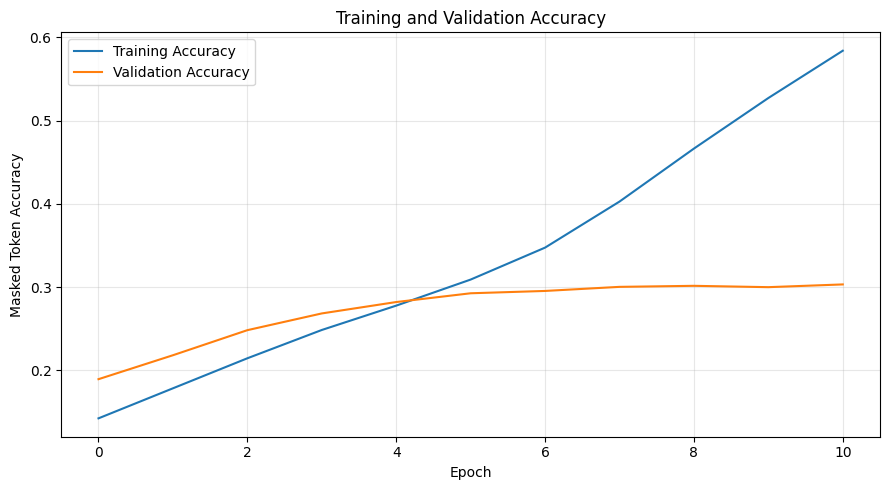

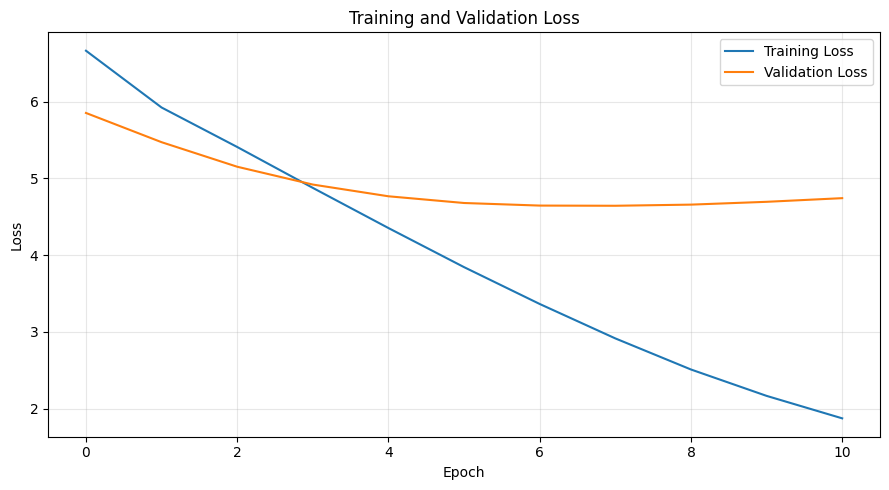


SAMPLE TRANSLATIONS

English : how are you
Telugu  : మీరు ఎలా ఉన్నారు

English : what is your name
Telugu  : మీ పేరు ఏమిటి

English : good morning
Telugu  : ప్రియమైన <unk>

English : i am a student
Telugu  : నేను ఒక <unk>

English : this is a book
Telugu  : ఇది పుస్తకం

Generating Test Predictions...
Evaluation Samples: 500

FINAL TEST PERFORMANCE METRICS
BLEU-1 Score        : 0.1834
BLEU-2 Score        : 0.0765
BLEU-3 Score        : 0.0312
METEOR Score        : 0.1373
ROUGE-1 Recall      : 0.2152
ROUGE-2 Recall      : 0.0484
ROUGE-3 Recall      : 0.0062
Word Error Rate     : 0.9214
Character Error Rate: 0.7776

NOTE:
ROUGE-1/2/3 are recall-oriented metrics.
Lower WER and CER indicate better performance.


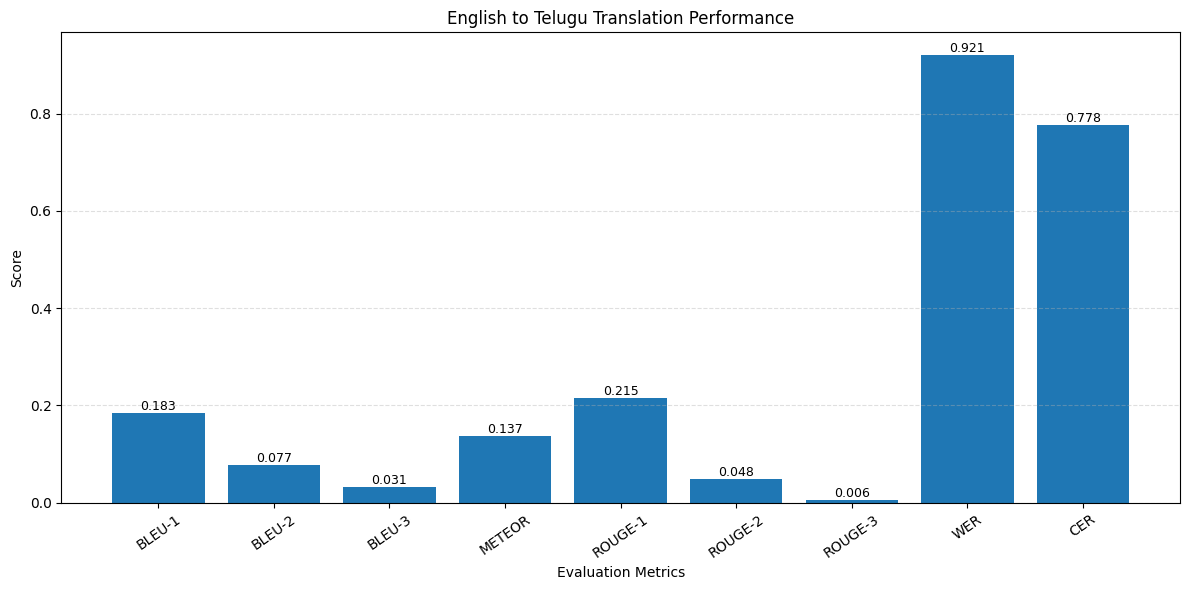


FINAL TRANSLATION EXAMPLES

English   : this means working together and sharing information frequently in order to deliver high quality results
Actual    : దీని అర్థం అధిక నాణ్యత ఫలితాలను అందించడానికి కలిసి పనిచేయడం మరియు సమాచారాన్ని తరచుగా పంచుకోవడం
Predicted : ఇది మరియు వినియోగదారులు వినియోగదారులు తమ <unk> నుండి <unk> <unk> <unk> <unk> <unk>

English   : i had a bad day today
Actual    : ఈ రోజు నాకు చెడ్డ రోజు వచ్చింది
Predicted : ఈ రోజు నాకు బిజీగా ఉన్నాను

English   : this is especially helpful for people who enjoy outdoor activities and want to stay hydrated without having to carry heavy water bottles
Actual    : ఆరుబయట కార్యకలాపాలను ఆస్వాదించే మరియు భారీ నీటి సీసాలను తీసుకెళ్లకుండా హైడ్రేటెడ్ గా ఉండాలనుకునే వ్యక్తులకు ఇది ముఖ్యంగా సహాయపడుతుంది
Predicted : ఇది ఆరోగ్యకరమైన మరియు ప్రశాంతమైన మద్దతు ఇవ్వడానికి మరియు ఆరోగ్యకరమైన అనుభవాన్ని అందించడానికి సౌకర్యవంతమైన ఆహార చర్యలు తీసుకోవడం కూడా ఇది సహాయపడుతుంది

English   : we will keep you updated regarding any further developments
Actu

In [ ]:
# ============================================================
# ENGLISH TO TELUGU NEURAL MACHINE TRANSLATION
# LSTM ENCODER-DECODER WITH ATTENTION
# ============================================================

# 1. IMPORT LIBRARIES
import re
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import nltk

warnings.filterwarnings("ignore")

from collections import Counter
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense,
    Attention, Concatenate
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from nltk.translate.bleu_score import (
    corpus_bleu, SmoothingFunction
)
from nltk.translate.meteor_score import meteor_score

nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

print("TensorFlow Version:", tf.__version__)


# ============================================================
# 2. LOAD DATASET
# ============================================================

url = (
    "https://huggingface.co/datasets/"
    "HackHedron/English_Telugu_Parallel_Corpus/"
    "resolve/main/English-Telugu%20Parallel%20Corpus%20Dataset.csv"
)

df = pd.read_csv(url)

print("\nOriginal Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())

df = df[["english", "telugu"]].copy()
df.columns = ["English", "Telugu"]
df = df.dropna()


# ============================================================
# 3. TEXT PREPROCESSING AND CLEANING
# ============================================================

def clean_english(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def clean_telugu(text):
    text = str(text)
    text = re.sub(r"[^\u0C00-\u0C7F\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


df["English"] = df["English"].apply(clean_english)
df["Telugu"] = df["Telugu"].apply(clean_telugu)

df = df[
    (df["English"].str.len() > 0) &
    (df["Telugu"].str.len() > 0)
].drop_duplicates().reset_index(drop=True)

print("\nAfter Cleaning:", df.shape)

print("\nSample Preprocessed Sentences:")
for i in range(min(5, len(df))):
    print("English:", df.iloc[i]["English"])
    print("Telugu :", df.iloc[i]["Telugu"])
    print()


# ============================================================
# 4. FILTER LONG SENTENCES AND SELECT DATA
# ============================================================

MAX_SAMPLES = 30000
MAX_LENGTH = 30

# Filter long sentences before tokenization
df["English_Length"] = df["English"].str.split().str.len()
df["Telugu_Length"] = df["Telugu"].str.split().str.len()

df = df[
    (df["English_Length"] <= MAX_LENGTH - 2) &
    (df["Telugu_Length"] <= MAX_LENGTH - 2)
].copy()

if len(df) > MAX_SAMPLES:
    df = df.sample(
        MAX_SAMPLES,
        random_state=42
    ).reset_index(drop=True)

df = df.drop(
    columns=["English_Length", "Telugu_Length"]
).reset_index(drop=True)

# Add special tokens to target sentences
df["Telugu"] = (
    "<start> " + df["Telugu"] + " <end>"
)

print("\nSamples Used:", len(df))


# ============================================================
# 5. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nTraining Samples  :", len(train_df))
print("Validation Samples:", len(val_df))
print("Testing Samples   :", len(test_df))


# ============================================================
# 6. WORD TOKENIZATION
# ============================================================

# Limit vocabulary to reduce memory and rare-word noise
MAX_ENGLISH_VOCAB = 15000
MAX_TELUGU_VOCAB = 20000

english_tokenizer = Tokenizer(
    num_words=MAX_ENGLISH_VOCAB,
    oov_token="<unk>",
    filters="",
    lower=True
)

telugu_tokenizer = Tokenizer(
    num_words=MAX_TELUGU_VOCAB,
    oov_token="<unk>",
    filters="",
    lower=False
)

english_tokenizer.fit_on_texts(train_df["English"])
telugu_tokenizer.fit_on_texts(train_df["Telugu"])

english_vocab_size = min(
    MAX_ENGLISH_VOCAB,
    len(english_tokenizer.word_index) + 1
)

telugu_vocab_size = min(
    MAX_TELUGU_VOCAB,
    len(telugu_tokenizer.word_index) + 1
)

print("\nEnglish Vocabulary:", english_vocab_size)
print("Telugu Vocabulary :", telugu_vocab_size)


# ============================================================
# 7. CONVERT TEXT TO INTEGER SEQUENCES
# ============================================================

def make_sequences(data):

    encoder_seq = english_tokenizer.texts_to_sequences(
        data["English"]
    )

    decoder_seq = telugu_tokenizer.texts_to_sequences(
        data["Telugu"]
    )

    encoder_seq = pad_sequences(
        encoder_seq,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    decoder_seq = pad_sequences(
        decoder_seq,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    # Teacher forcing:
    # Input:  <start> word1 word2
    # Target: word1 word2 <end>

    decoder_input = decoder_seq[:, :-1]
    decoder_target = decoder_seq[:, 1:]

    return encoder_seq, decoder_input, decoder_target


X_train, D_train, Y_train = make_sequences(train_df)
X_val, D_val, Y_val = make_sequences(val_df)
X_test, D_test, Y_test = make_sequences(test_df)

DECODER_LENGTH = MAX_LENGTH - 1

print("\nEncoder Shape:", X_train.shape)
print("Decoder Shape:", D_train.shape)
print("Target Shape :", Y_train.shape)


# ============================================================
# 8. MASK PADDING TOKENS
# ============================================================

# Zero is padding. Padding positions must not contribute
# to training loss or weighted accuracy.

W_train = (Y_train != 0).astype("float32")
W_val = (Y_val != 0).astype("float32")
W_test = (Y_test != 0).astype("float32")


# ============================================================
# 9. BUILD ENCODER
# ============================================================

EMBEDDING_DIM = 128
LSTM_UNITS = 256

encoder_inputs = Input(
    shape=(MAX_LENGTH,),
    name="Encoder_Input"
)

encoder_embedding_layer = Embedding(
    input_dim=english_vocab_size,
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name="English_Embedding"
)

encoder_embedding = encoder_embedding_layer(
    encoder_inputs
)

encoder_lstm = LSTM(
    LSTM_UNITS,
    return_sequences=True,
    return_state=True,
    name="Encoder_LSTM"
)

encoder_outputs, encoder_h, encoder_c = encoder_lstm(
    encoder_embedding
)


# ============================================================
# 10. BUILD DECODER
# ============================================================

decoder_inputs = Input(
    shape=(DECODER_LENGTH,),
    name="Decoder_Input"
)

decoder_embedding_layer = Embedding(
    input_dim=telugu_vocab_size,
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name="Telugu_Embedding"
)

decoder_embedding = decoder_embedding_layer(
    decoder_inputs
)

decoder_lstm = LSTM(
    LSTM_UNITS,
    return_sequences=True,
    return_state=True,
    name="Decoder_LSTM"
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=[encoder_h, encoder_c]
)


# ============================================================
# 11. ATTENTION MECHANISM
# ============================================================

attention_layer = Attention(name="Attention")

context_vector = attention_layer(
    [decoder_outputs, encoder_outputs]
)

decoder_combined = Concatenate(
    axis=-1,
    name="Attention_Concatenate"
)([decoder_outputs, context_vector])


# ============================================================
# 12. OUTPUT LAYER
# ============================================================

output_layer = Dense(
    telugu_vocab_size,
    activation="softmax",
    name="Telugu_Output"
)

outputs = output_layer(decoder_combined)


# ============================================================
# 13. CREATE AND COMPILE MODEL
# ============================================================

model = Model(
    [encoder_inputs, decoder_inputs],
    outputs
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    weighted_metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="token_accuracy"
        )
    ]
)

print("\nMODEL ARCHITECTURE")
model.summary()


# ============================================================
# 14. TRAIN MODEL
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    [X_train, D_train],
    Y_train,
    sample_weight=W_train,

    validation_data=(
        [X_val, D_val],
        Y_val,
        W_val
    ),

    epochs=20,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)


# ============================================================
# 15. TEST MODEL
# ============================================================

test_results = model.evaluate(
    [X_test, D_test],
    Y_test,
    sample_weight=W_test,
    verbose=0,
    return_dict=True
)

print("\nTEST RESULTS")
print("Test Loss:", round(test_results["loss"], 4))
print(
    "Masked Token Accuracy:",
    round(test_results["token_accuracy"], 4)
)


# ============================================================
# 16. TRAINING ACCURACY GRAPH
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    history.history["token_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_token_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Masked Token Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 17. TRAINING LOSS GRAPH
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 18. PREPARE DECODER WORD DICTIONARY
# ============================================================

reverse_telugu_index = {
    value: key
    for key, value in telugu_tokenizer.word_index.items()
}

start_token = telugu_tokenizer.word_index["<start>"]
end_token = telugu_tokenizer.word_index["<end>"]


# ============================================================
# 19. ENGLISH TO TELUGU TRANSLATION
# ============================================================

def translate_sentence(sentence):

    sentence = clean_english(sentence)

    sequence = english_tokenizer.texts_to_sequences(
        [sentence]
    )

    sequence = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    target_sequence = [start_token]
    translated_words = []

    for _ in range(DECODER_LENGTH):

        decoder_input = pad_sequences(
            [target_sequence],
            maxlen=DECODER_LENGTH,
            padding="post",
            truncating="post"
        )

        prediction = model.predict(
            [sequence, decoder_input],
            verbose=0
        )

        position = len(target_sequence) - 1

        next_token = int(
            np.argmax(prediction[0, position])
        )

        if next_token == end_token or next_token == 0:
            break

        word = reverse_telugu_index.get(
            next_token,
            "<unk>"
        )

        if word not in ["<start>", "<end>"]:
            translated_words.append(word)

        target_sequence.append(next_token)

    return " ".join(translated_words)


# ============================================================
# 20. SAMPLE TRANSLATIONS
# ============================================================

sample_sentences = [
    "how are you",
    "what is your name",
    "good morning",
    "i am a student",
    "this is a book"
]

print("\nSAMPLE TRANSLATIONS")
print("=" * 60)

for sentence in sample_sentences:
    print("\nEnglish :", sentence)
    print("Telugu  :", translate_sentence(sentence))


# ============================================================
# 21. GENERATE TEST PREDICTIONS
# ============================================================

# Increase to evaluate more sentences.
# Evaluation time increases with this value.

EVAL_SAMPLES = min(500, len(test_df))

test_references = []
test_predictions = []

print("\nGenerating Test Predictions...")

for i in range(EVAL_SAMPLES):

    reference = test_df.iloc[i]["Telugu"]

    reference = (
        reference
        .replace("<start>", "")
        .replace("<end>", "")
        .strip()
    )

    prediction = translate_sentence(
        test_df.iloc[i]["English"]
    )

    test_references.append(reference)
    test_predictions.append(prediction)

print("Evaluation Samples:", EVAL_SAMPLES)


# ============================================================
# 22. TOKENIZE REFERENCES AND PREDICTIONS
# ============================================================

reference_tokens = [
    text.split()
    for text in test_references
]

prediction_tokens = [
    text.split()
    for text in test_predictions
]


# ============================================================
# 23. BLEU-1, BLEU-2 AND BLEU-3
# ============================================================

smooth = SmoothingFunction().method1

references_for_bleu = [
    [ref]
    for ref in reference_tokens
]

bleu1 = corpus_bleu(
    references_for_bleu,
    prediction_tokens,
    weights=(1, 0, 0, 0),
    smoothing_function=smooth
)

bleu2 = corpus_bleu(
    references_for_bleu,
    prediction_tokens,
    weights=(0.5, 0.5, 0, 0),
    smoothing_function=smooth
)

bleu3 = corpus_bleu(
    references_for_bleu,
    prediction_tokens,
    weights=(1/3, 1/3, 1/3, 0),
    smoothing_function=smooth
)


# ============================================================
# 24. METEOR SCORE
# ============================================================

meteor_scores = []

for reference, prediction in zip(
    reference_tokens,
    prediction_tokens
):

    if len(prediction) == 0:
        meteor_scores.append(0.0)
    else:
        meteor_scores.append(
            meteor_score([reference], prediction)
        )

meteor = float(np.mean(meteor_scores))


# ============================================================
# 25. ROUGE-1, ROUGE-2 AND ROUGE-3
# ============================================================

# Calculate n-gram recall directly using Telugu tokens.
# Multiset overlap handles repeated n-grams correctly.

def get_ngrams(tokens, n):
    return [
        tuple(tokens[i:i+n])
        for i in range(len(tokens) - n + 1)
    ]


def rouge_n_recall(reference, prediction, n):

    ref_ngrams = Counter(
        get_ngrams(reference, n)
    )

    pred_ngrams = Counter(
        get_ngrams(prediction, n)
    )

    total = sum(ref_ngrams.values())

    if total == 0:
        return 0.0

    overlap = sum(
        min(count, pred_ngrams[gram])
        for gram, count in ref_ngrams.items()
    )

    return overlap / total


rouge1_scores = []
rouge2_scores = []
rouge3_scores = []

for reference, prediction in zip(
    reference_tokens,
    prediction_tokens
):

    rouge1_scores.append(
        rouge_n_recall(reference, prediction, 1)
    )

    rouge2_scores.append(
        rouge_n_recall(reference, prediction, 2)
    )

    rouge3_scores.append(
        rouge_n_recall(reference, prediction, 3)
    )


rouge1 = float(np.mean(rouge1_scores))
rouge2 = float(np.mean(rouge2_scores))
rouge3 = float(np.mean(rouge3_scores))


# ============================================================
# 26. EDIT DISTANCE
# ============================================================

def edit_distance(reference, hypothesis):

    m = len(reference)
    n = len(hypothesis)

    previous = list(range(n + 1))

    for i in range(1, m + 1):

        current = [i] + [0] * n

        for j in range(1, n + 1):

            if reference[i - 1] == hypothesis[j - 1]:
                current[j] = previous[j - 1]
            else:
                current[j] = 1 + min(
                    previous[j],
                    current[j - 1],
                    previous[j - 1]
                )

        previous = current

    return previous[n]


# ============================================================
# 27. WORD ERROR RATE AND CHARACTER ERROR RATE
# ============================================================

total_word_errors = 0
total_reference_words = 0

total_char_errors = 0
total_reference_chars = 0

for reference, prediction in zip(
    reference_tokens,
    prediction_tokens
):

    total_word_errors += edit_distance(
        reference,
        prediction
    )

    total_reference_words += len(reference)


for reference, prediction in zip(
    test_references,
    test_predictions
):

    total_char_errors += edit_distance(
        list(reference),
        list(prediction)
    )

    total_reference_chars += len(reference)


wer = (
    total_word_errors / total_reference_words
    if total_reference_words else 0.0
)

cer = (
    total_char_errors / total_reference_chars
    if total_reference_chars else 0.0
)


# ============================================================
# 28. FINAL TEST PERFORMANCE METRICS
# ============================================================

metric_names = [
    "BLEU-1",
    "BLEU-2",
    "BLEU-3",
    "METEOR",
    "ROUGE-1",
    "ROUGE-2",
    "ROUGE-3",
    "WER",
    "CER"
]

metric_values = [
    bleu1,
    bleu2,
    bleu3,
    meteor,
    rouge1,
    rouge2,
    rouge3,
    wer,
    cer
]

print("\n" + "=" * 60)
print("FINAL TEST PERFORMANCE METRICS")
print("=" * 60)

print(f"BLEU-1 Score        : {bleu1:.4f}")
print(f"BLEU-2 Score        : {bleu2:.4f}")
print(f"BLEU-3 Score        : {bleu3:.4f}")
print(f"METEOR Score        : {meteor:.4f}")
print(f"ROUGE-1 Recall      : {rouge1:.4f}")
print(f"ROUGE-2 Recall      : {rouge2:.4f}")
print(f"ROUGE-3 Recall      : {rouge3:.4f}")
print(f"Word Error Rate     : {wer:.4f}")
print(f"Character Error Rate: {cer:.4f}")

print("=" * 60)

print("\nNOTE:")
print("ROUGE-1/2/3 are recall-oriented metrics.")
print("Lower WER and CER indicate better performance.")


# ============================================================
# 29. BAR GRAPH OF ALL NINE METRICS
# ============================================================

plt.figure(figsize=(12, 6))

bars = plt.bar(
    metric_names,
    metric_values
)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("English to Telugu Translation Performance")

plt.xticks(rotation=35)

for bar, value in zip(bars, metric_values):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()


# ============================================================
# 30. FINAL TRANSLATION COMPARISON
# ============================================================

print("\nFINAL TRANSLATION EXAMPLES")
print("=" * 60)

for i in range(min(10, EVAL_SAMPLES)):

    print("\nEnglish   :", test_df.iloc[i]["English"])
    print("Actual    :", test_references[i])
    print("Predicted :", test_predictions[i])

print("\nPROGRAM COMPLETED")